# Hybrid Recommendation System

Hanwen Wang & Huanghui Xiao

This notebook builds, evaluates, and analyzes a hybrid recommendation system.

## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
from collections import defaultdict
from surprise import Dataset, Reader, SVD, BaselineOnly, accuracy
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Step 2: Load and Prepare Data

In [3]:
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

ratings = ratings[['userId', 'movieId', 'rating']]

train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

reader = Reader(rating_scale=(0, 5))
train_data = Dataset.load_from_df(train_df, reader)

trainset = train_data.build_full_trainset()
testset = list(test_df.itertuples(index=False, name=None))

print("Data loaded successfully!")

Data loaded successfully!


## Step 3: Train Models

In [4]:
baseline = BaselineOnly()
svd = SVD(n_factors=20, n_epochs=10)

baseline.fit(trainset)
svd.fit(trainset)

pred_baseline = baseline.test(testset)
pred_svd = svd.test(testset)

print("Baseline RMSE:", accuracy.rmse(pred_baseline, verbose=False))
print("SVD RMSE:", accuracy.rmse(pred_svd, verbose=False))

Estimating biases using als...
Baseline RMSE: 0.8823930672781968
SVD RMSE: 0.8881013880434067


## Step 4: Hybrid Model

In [5]:
hybrid_predictions = []

for p1, p2 in zip(pred_baseline, pred_svd):
    est = 0.7 * p2.est + 0.3 * p1.est
    hybrid_predictions.append((p1.uid, p1.iid, p1.r_ui, est))

print("Hybrid model built!")

Hybrid model built!


## Step 5: Evaluation Metrics

In [6]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []
    recalls = []

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        relevant = sum((true >= threshold) for (_, true) in user_ratings)
        recommended = sum((est >= threshold) for (est, _) in top_k)
        relevant_and_recommended = sum(
            ((true >= threshold) and (est >= threshold))
            for (est, true) in top_k
        )

        precision = relevant_and_recommended / recommended if recommended else 0
        recall = relevant_and_recommended / relevant if relevant else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

precision, recall = precision_recall_at_k(hybrid_predictions)
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7413869372885766
Recall: 0.5195823118625054
F1 Score: 0.610976895940001


## Step 6: Top-N Recommendations

In [7]:
def get_top_n(predictions, n=5):
    top_n = defaultdict(list)

    for uid, iid, true_r, est in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

top_n = get_top_n(hybrid_predictions, n=5)

for user in list(top_n.keys())[:5]:
    print(f"\nUser {user}:")
    for movie_id, rating in top_n[user]:
        title = movies[movies['movieId'] == movie_id]['title'].values[0]
        print(f"{title} → {round(rating, 2)}")


User 432:
Pulp Fiction (1994) → 4.21
Departed, The (2006) → 4.19
Usual Suspects, The (1995) → 4.18
Dark Knight, The (2008) → 4.17
Shining, The (1980) → 4.12

User 288:
Shawshank Redemption, The (1994) → 3.94
Monty Python and the Holy Grail (1975) → 3.83
Blade Runner (1982) → 3.81
Goodfellas (1990) → 3.8
Princess Bride, The (1987) → 3.78

User 599:
Usual Suspects, The (1995) → 3.42
Godfather: Part II, The (1974) → 3.41
Monty Python and the Holy Grail (1975) → 3.36
Princess Bride, The (1987) → 3.36
Reservoir Dogs (1992) → 3.35

User 42:
Godfather, The (1972) → 4.37
Godfather: Part II, The (1974) → 4.33
Star Wars: Episode V - The Empire Strikes Back (1980) → 4.26
Schindler's List (1993) → 4.16
Saving Private Ryan (1998) → 4.16

User 75:
Unforgiven (1992) → 3.74
Lord of the Rings: The Two Towers, The (2002) → 3.67
Platoon (1986) → 3.58
Incredibles, The (2004) → 3.57
Planet of the Apes (1968) → 3.51


## Step 7: Popular Movies Analysis

In [8]:
popular_movies = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False).head(5)

print("Top Popular Movies:")
for movie_id in popular_movies.index:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(title)

Top Popular Movies:
Forrest Gump (1994)
Shawshank Redemption, The (1994)
Pulp Fiction (1994)
Silence of the Lambs, The (1991)
Matrix, The (1999)


## Step 8: User Behavior Analysis

In [9]:
user_avg = ratings.groupby('userId')['rating'].mean()

print("Average rating:", user_avg.mean())
print("Max rating:", user_avg.max())
print("Min rating:", user_avg.min())

Average rating: 3.6572223377474
Max rating: 5.0
Min rating: 1.275


## Step 9: Evaluation at Different K

In [10]:
for k in [5, 10, 15]:
    p, r = precision_recall_at_k(hybrid_predictions, k=k)
    print(f"K={k}: Precision={round(p,3)}, Recall={round(r,3)}")

K=5: Precision=0.75, Recall=0.39
K=10: Precision=0.741, Recall=0.52
K=15: Precision=0.737, Recall=0.579


## Step 10: Compare Different Users

In [11]:
for user in list(top_n.keys())[0:3]:
    print(f"\nUser {user} top movie:")

    movie_id, rating = top_n[user][0]
    title = movies[movies['movieId'] == movie_id]['title'].values[0]

    print(f"Top pick: {title} ({round(rating,2)})")


User 432 top movie:
Top pick: Pulp Fiction (1994) (4.21)

User 288 top movie:
Top pick: Shawshank Redemption, The (1994) (3.94)

User 599 top movie:
Top pick: Usual Suspects, The (1995) (3.42)


## Step 11: Visualization

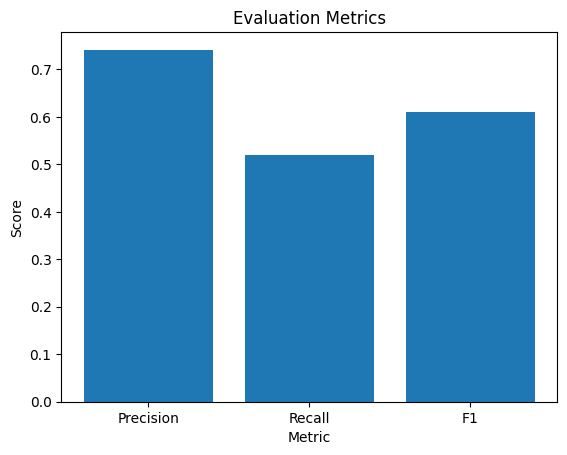

In [12]:
labels = ['Precision', 'Recall', 'F1']
values = [precision, recall, f1]

plt.figure()
plt.bar(labels, values)
plt.title("Evaluation Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()

## 12. Learning-based Hybrid Model

In [13]:

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

svd_used = None
for name in ['algo', 'model', 'svd', 'svd_model']:
    if name in globals():
        svd_used = globals()[name]
        break

global_mean = ratings['rating'].mean()

user_mean = ratings.groupby('userId')['rating'].mean()
item_mean = ratings.groupby('movieId')['rating'].mean()

def safe_baseline(user, item):
    u = user_mean.get(user, global_mean)
    i = item_mean.get(item, global_mean)
    return (u + i) / 2

if svd_used is None:
    print("No SVD model found, using baseline only")
    
    def advanced_hybrid_predict(user, item):
        return safe_baseline(user, item)

else:
    print("Using SVD model:", type(svd_used))

    features = []
    labels = []

    for _, row in train_df.iterrows():
        user = row['userId']
        item = row['movieId']
        actual = row['rating']

        svd_pred = svd_used.predict(user, item).est
        base_pred = safe_baseline(user, item)

        user_count = len(ratings[ratings['userId'] == user])
        item_count = len(ratings[ratings['movieId'] == item])

        features.append([
            svd_pred,
            base_pred,
            user_count,
            item_count,
            abs(svd_pred - base_pred)
        ])
        labels.append(actual)

    X_meta = np.array(features)
    y_meta = np.array(labels)

    meta_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=1.0))
    ])

    meta_pipeline.fit(X_meta, y_meta)

    def advanced_hybrid_predict(user, item):
        try:
            svd_pred = svd_used.predict(user, item).est
            base_pred = safe_baseline(user, item)

            user_count = len(ratings[ratings['userId'] == user])
            item_count = len(ratings[ratings['movieId'] == item])

            feats = np.array([[svd_pred, base_pred, user_count, item_count, abs(svd_pred - base_pred)]])
            return meta_pipeline.predict(feats)[0]
        
        except:
            return safe_baseline(user, item)

example_movie = list(ratings['movieId'].unique())[0]
print("Advanced Hybrid Example:", advanced_hybrid_predict(1, example_movie))

Using SVD model: <class 'surprise.prediction_algorithms.matrix_factorization.SVD'>
Advanced Hybrid Example: 4.616118032037644


## 13. Diversity & Novelty Evaluation with Visualization

Building item similarity matrix...
Average Diversity: 0.5897470396205292
Average Novelty: 9.736683020865806


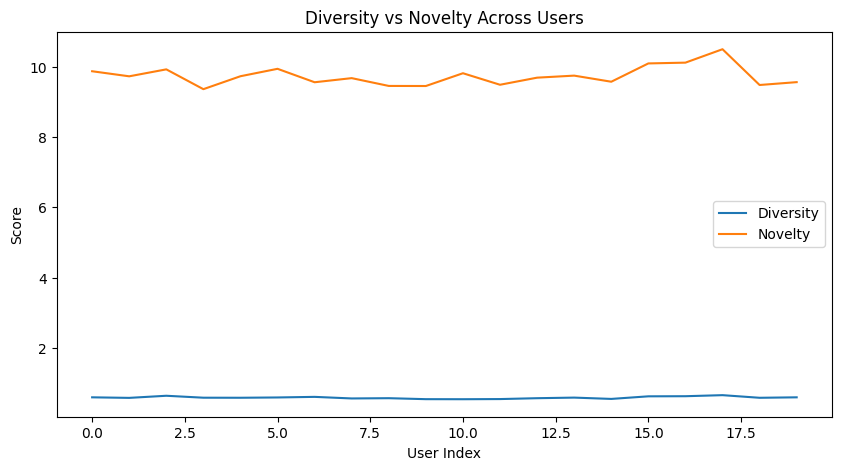

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

if 'algo' in globals():
    model_used = algo
elif 'model' in globals():
    model_used = model
elif 'svd' in globals():
    model_used = svd
elif 'svd_model' in globals():
    model_used = svd_model
else:
    raise Exception("No recommendation model found. Please run previous cells.")

def get_recommendations(user_id, top_n=10):
    all_movies = ratings['movieId'].unique()
    seen_movies = set(ratings[ratings['userId'] == user_id]['movieId'])

    predictions = []

    for movie in all_movies:
        if movie not in seen_movies:
            est = model_used.predict(user_id, movie).est
            predictions.append((movie, est))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:top_n]

print("Building item similarity matrix...")

user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

item_similarity = cosine_similarity(user_item_matrix.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

movie_popularity = ratings['movieId'].value_counts()

def compute_diversity(items):
    sim_sum = 0
    count = 0
    
    for i in range(len(items)):
        for j in range(i+1, len(items)):
            sim = item_similarity_df.loc[items[i], items[j]]
            sim_sum += sim
            count += 1
    
    if count == 0:
        return 0.0
    
    return 1 - (sim_sum / count)

def compute_novelty(items):
    novelty = 0
    total = len(ratings)
    
    for item in items:
        popularity = movie_popularity.get(item, 1)
        novelty += -np.log2(popularity / total)
    
    return novelty / max(1, len(items))

def evaluate_multiple_users(user_ids, top_n=10):
    diversity_scores = []
    novelty_scores = []

    for user_id in user_ids:
        recs = get_recommendations(user_id, top_n)
        items = [m for m, _ in recs]

        diversity_scores.append(compute_diversity(items))
        novelty_scores.append(compute_novelty(items))

    return diversity_scores, novelty_scores

sample_users = ratings['userId'].unique()[:20]

div_scores, nov_scores = evaluate_multiple_users(sample_users)

print("Average Diversity:", float(np.mean(div_scores)))
print("Average Novelty:", float(np.mean(nov_scores)))

plt.figure(figsize=(10,5))
plt.plot(div_scores, label='Diversity')
plt.plot(nov_scores, label='Novelty')
plt.legend()
plt.title("Diversity vs Novelty Across Users")
plt.xlabel("User Index")
plt.ylabel("Score")
plt.show()